------------------------------
ID Card Detected!
 Width:  820 pixels
 Height: 1305 pixels
------------------------------


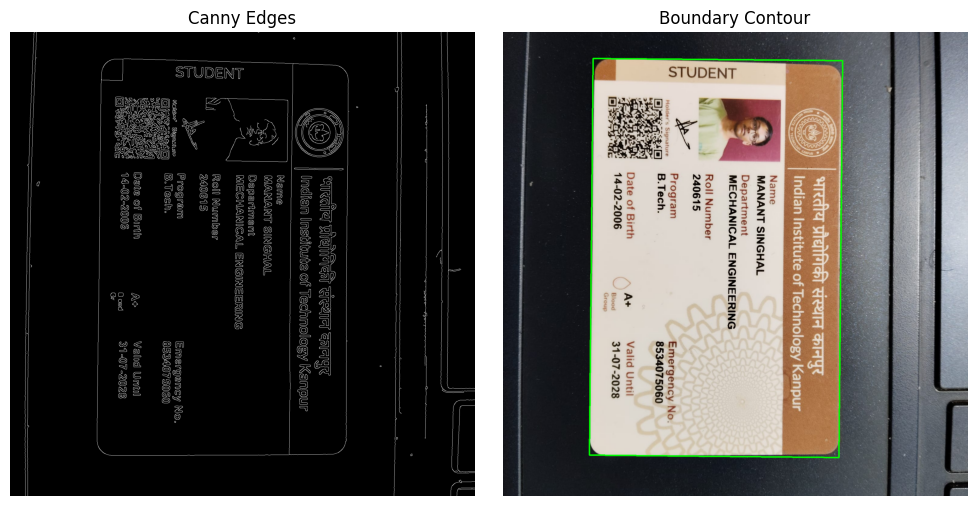

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_id_dimensions(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return
    output = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    edged = cv2.Canny(blurred, 50, 150)
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closed.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    id_card_rect = None

    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        
        if len(approx) == 4:
            id_card_rect = cv2.minAreaRect(c)
            break
    if id_card_rect is not None:
        box = cv2.boxPoints(id_card_rect)
        box = np.int64(box) 
        
        (w, h) = int(id_card_rect[1][0]), int(id_card_rect[1][1])

        cv2.drawContours(output, [box], 0, (0, 255, 0), 3)        
        print("-" * 30)
        print(f"ID Card Detected!")
        print(f" Width:  {w:} pixels")
        print(f" Height: {h:} pixels")
        print("-" * 30)
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(edged, cmap='gray')
        plt.title("Canny Edges")
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        plt.title("Boundary Contour")
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("Failed to detect a rectangular ID card.")

# Run the function
detect_id_dimensions('id_card.jpeg')